# **1. Import Library dan Load Dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import warnings
import os
import joblib
from urllib.parse import urlparse
import re
warnings.filterwarnings('ignore')
import seaborn as sns
import json
import time
import warnings
import os
import joblib
from urllib.parse import urlparse
import re
warnings.filterwarnings('ignore')

# ── Cari root proyek ──
if not os.path.exists('data') and os.path.exists(os.path.join('..', 'data')):
    os.chdir('..')
    print("Working dir ->", os.getcwd())

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix, classification_report, roc_auc_score
)
from sklearn.dummy import DummyClassifier

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False

RANDOM_STATE = 42
SAMPLE_SIZE = 15000
print(f"Setup selesai. SMOTE tersedia: {HAS_IMBLEARN}")

Working dir -> D:\uas ML
Setup selesai. SMOTE tersedia: True


In [2]:
# Load Dataset
df = pd.read_csv('data/PhiUSIIL_Phishing_URL_Dataset.csv')
print(f"Dataset dimuat: {df.shape[0]:,} baris x {df.shape[1]} kolom")
df.head()

Dataset dimuat: 235,795 baris x 56 kolom


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


---
# **2. Preprocessing**

### a. Informasi Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation           

### b. Cek Missing Value, Duplikat, dan Outlier

AUDIT DATA

Missing values total: 0
Tidak ada missing values!

Data duplikat: 0

Baris mengandung outlier: 209188

Outlier per kolom (top 10):
NoOfSubDomain      57389
Pay                55885
NoOfDegitsInURL    51461
DegitRatioInURL    51461
IsHTTPS            51256
NoOfEmptyRef       38885
NoOfiFrame         34441
HasTitle           32714
NoOfURLRedirect    31464
Bank               29967
dtype: int64


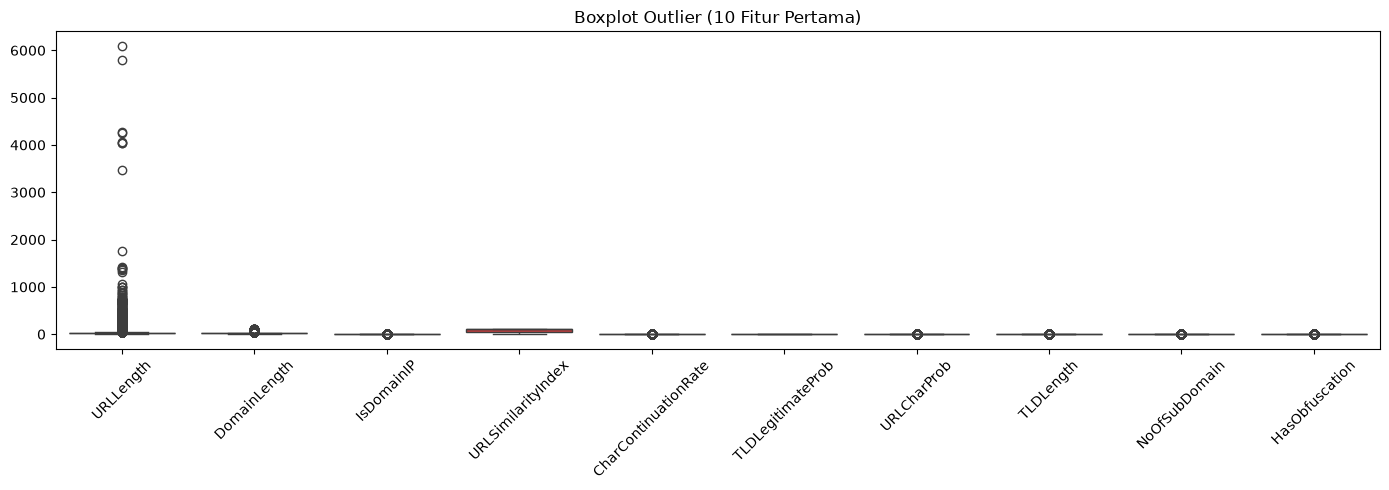


Distribusi Target:
label
1    134850
0    100945
Name: count, dtype: int64
Rasio Imbalance: 1.3359

Potensi Data Leakage:
Kolom string: FILENAME, URL, Domain, TLD, Title -> akan di-drop
Karena bukan fitur prediktif numerik dan berisi identitas unik.


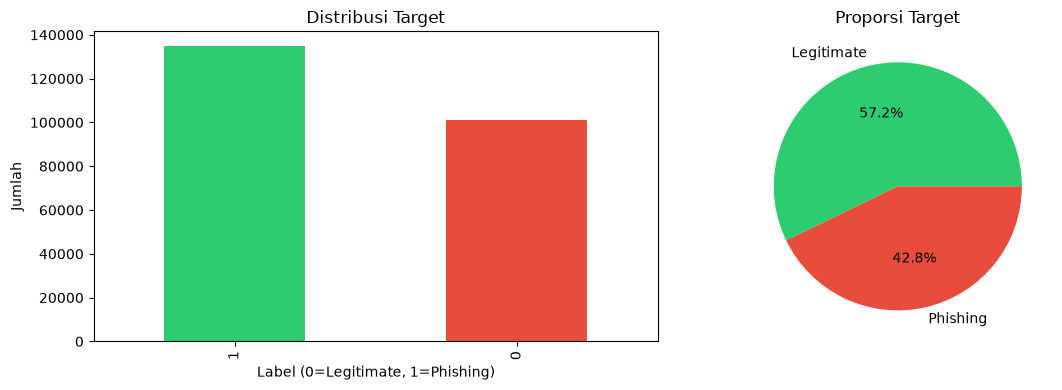

In [4]:
print("=" * 60)
print("AUDIT DATA")
print("=" * 60)

# 1. Missing Values
missing = df.isnull().sum()
print(f"\nMissing values total: {missing.sum()}")
if missing.sum() == 0:
    print("Tidak ada missing values!")

# 2. Duplikat
duplicate = df.duplicated().sum()
print(f"\nData duplikat: {duplicate}")

# 3. Outlier (IQR)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) |
                (df[numerical_cols] > (Q3 + 1.5 * IQR)))
print(f"\nBaris mengandung outlier: {outlier_mask.any(axis=1).sum()}")
print(f"\nOutlier per kolom (top 10):")
print(outlier_mask.sum().sort_values(ascending=False).head(10))

# Boxplot
plt.figure(figsize=(14, 5))
sns.boxplot(data=df[numerical_cols[:10]])
plt.title("Boxplot Outlier (10 Fitur Pertama)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Distribusi target
print(f"\nDistribusi Target:")
print(df['label'].value_counts())
print(f"Rasio Imbalance: {df['label'].value_counts().max() / df['label'].value_counts().min():.4f}")

# 5. Data Leakage Check
print(f"\nPotensi Data Leakage:")
print("Kolom string: FILENAME, URL, Domain, TLD, Title -> akan di-drop")
print("Karena bukan fitur prediktif numerik dan berisi identitas unik.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribusi Target')
axes[0].set_xlabel('Label (0=Legitimate, 1=Phishing)')
axes[0].set_ylabel('Jumlah')
df['label'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                 colors=['#2ecc71', '#e74c3c'],
                                 labels=['Legitimate', 'Phishing'])
axes[1].set_title('Proporsi Target')
plt.tight_layout()
plt.show()

### c. Sampling, Cleaning, dan Encode

Sampling: 235,795 -> 15,000 baris
Duplikat dihapus: 0, tersisa 15000
Drop kolom non-numerik: 51 kolom tersisa
Data setelah cleaning: (15000, 23), fitur: 22


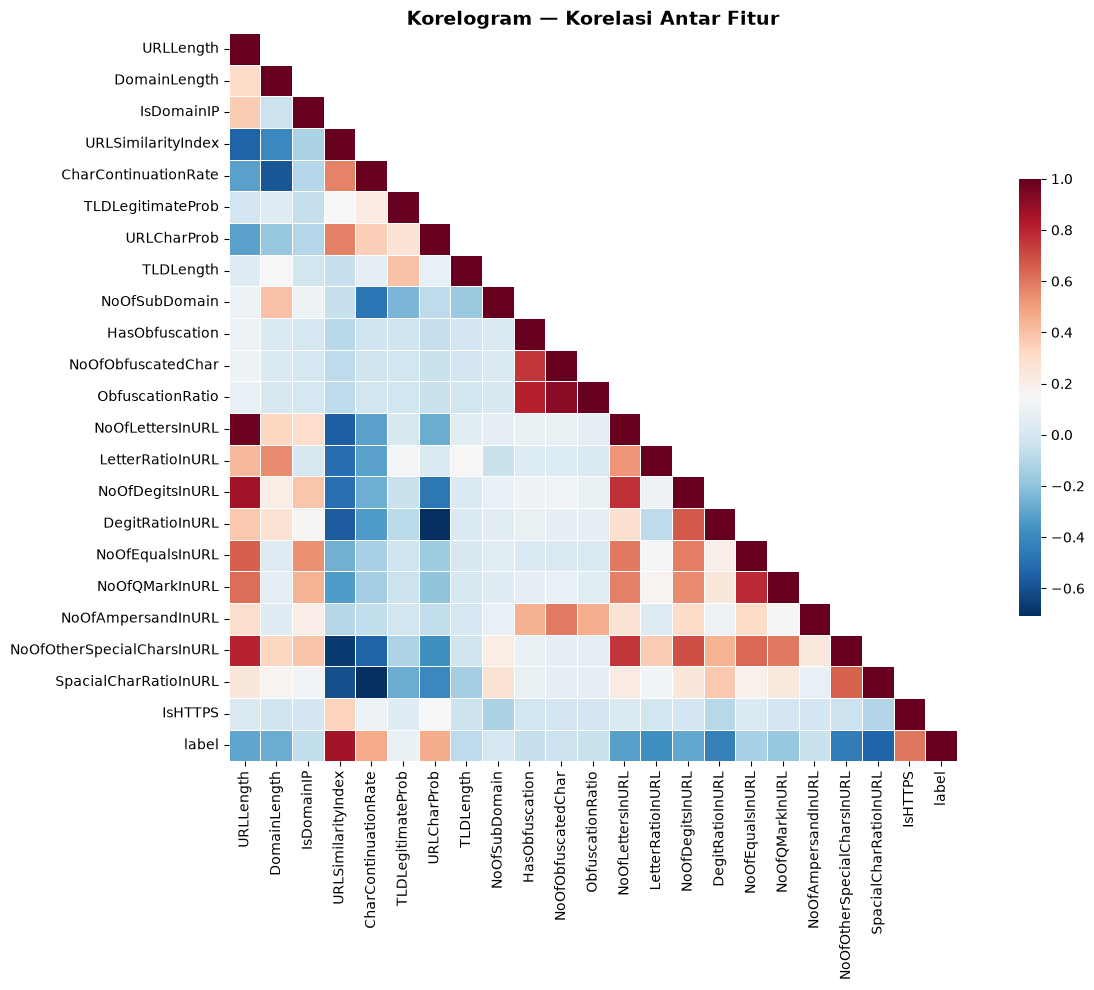

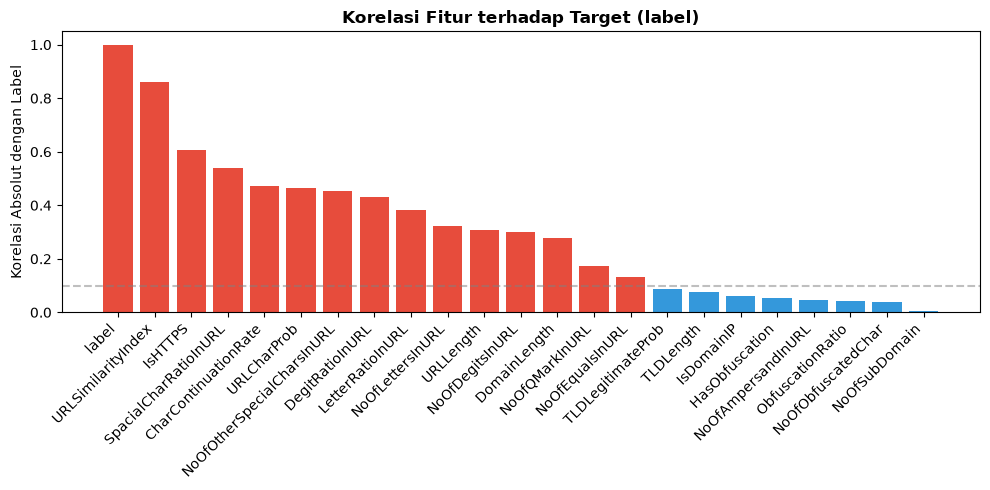

In [5]:
# Sampling
if len(df) > SAMPLE_SIZE:
    df_sample = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"Sampling: {len(df):,} -> {len(df_sample):,} baris")
else:
    df_sample = df.copy().reset_index(drop=True)

# Drop duplikat
n_before = len(df_sample)
df_sample = df_sample.drop_duplicates().reset_index(drop=True)
print(f"Duplikat dihapus: {n_before - len(df_sample)}, tersisa {len(df_sample)}")

# Drop kolom non-numerik (leakage)
cols_drop = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
df_sample = df_sample.drop(columns=[c for c in cols_drop if c in df_sample.columns])
print(f"Drop kolom non-numerik: {df_sample.shape[1]} kolom tersisa")

# Seleksi 22 fitur URL-Based
url_features = [
    'URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex',
    'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength',
    'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
    'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL',
    'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL',
    'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS'
]
avail_feat = [c for c in url_features if c in df_sample.columns]

data_clean = df_sample[avail_feat + ['label']].copy()
print(f"Data setelah cleaning: {data_clean.shape}, fitur: {len(avail_feat)}")
data_clean.head()

# ── Korelogram ──
plt.figure(figsize=(14, 10))
corr = data_clean.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=False, fmt='.2f', cmap='RdBu_r',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.6})
plt.title('Korelogram — Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Label encoding untuk korelogram dengan target
if 'label' in data_clean.columns:
    corr_label = data_clean.corr(numeric_only=True)['label'].abs().sort_values(ascending=False)
    plt.figure(figsize=(10, 5))
    colors = ['#e74c3c' if v >= 0.1 else '#3498db' for v in corr_label.values]
    plt.bar(range(len(corr_label)), corr_label.values, color=colors)
    plt.xticks(range(len(corr_label)), corr_label.index, rotation=45, ha='right')
    plt.ylabel('Korelasi Absolut dengan Label')
    plt.title('Korelasi Fitur terhadap Target (label)', fontweight='bold')
    plt.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

### d. Cek Imbalance Data

Distribusi kelas:
label
1    8614
0    6386
Name: count, dtype: int64


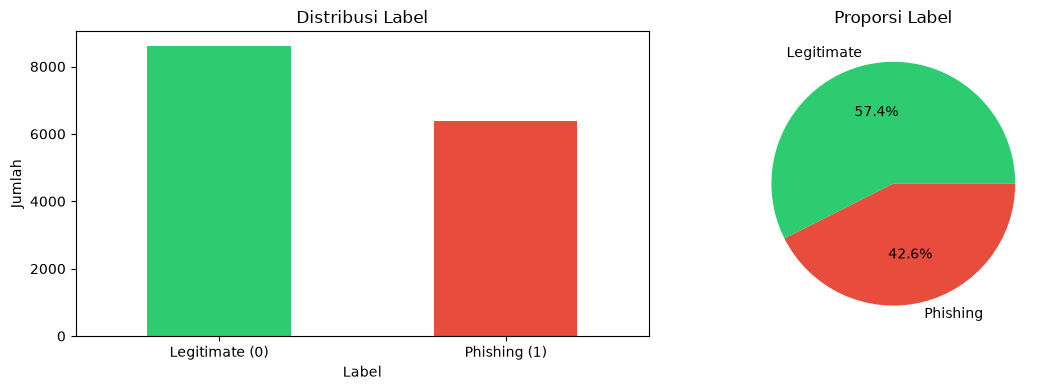

In [6]:
print("Distribusi kelas:")
print(data_clean['label'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data_clean['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribusi Label')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Jumlah')
axes[0].set_xticklabels(['Legitimate (0)', 'Phishing (1)'], rotation=0)
data_clean['label'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                         colors=['#2ecc71', '#e74c3c'],
                                         labels=['Legitimate', 'Phishing'])
axes[1].set_title('Proporsi Label')
plt.tight_layout()
plt.show()

### e. Normalisasi (Scaling)

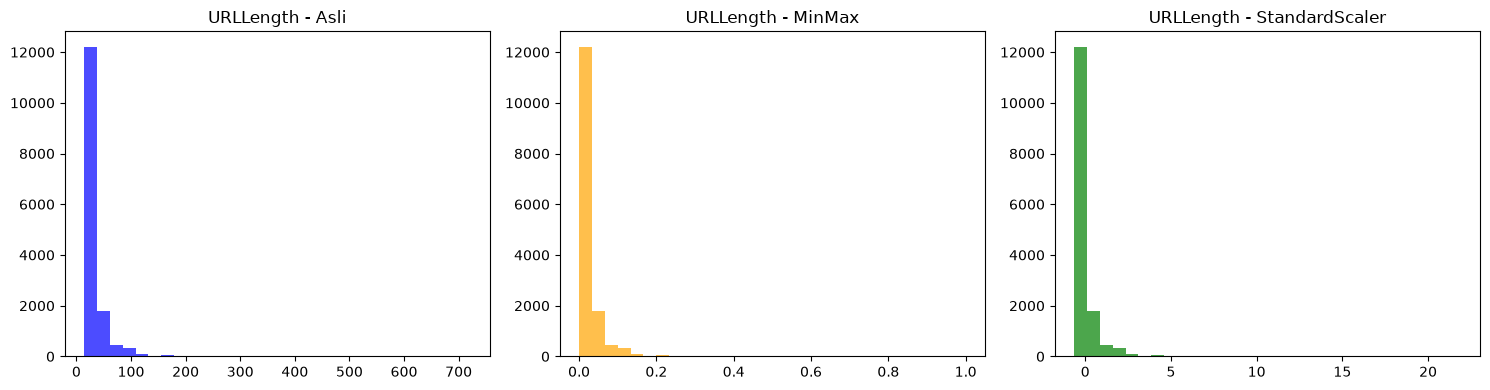

Data setelah StandardScaler:


,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,label
count,1.500000e+04,1.500000e+04,1.500000e+04,1.500000e+04,1.500000e+04,1.500000e+04,1.500000e+04,1.500000e+04,1.500000e+04,1.500000e+04,...,1.500000e+04,1.500000e+04,1.500000e+04,1.500000e+04,1.500000e+04,1.500000e+04,1.500000e+04,1.500000e+04,1.500000e+04,15000.000000
mean,6.252776e-17,-8.337035e-17,-1.421085e-18,-2.970069e-16,-6.745419e-16,1.184238e-16,-8.900732e-16,-9.189686e-17,3.789561e-17,1.800042e-17,...,-4.538000e-16,1.705303e-17,-8.881784e-17,1.468455e-17,1.042129e-17,-3.079019e-18,-1.468455e-17,-1.278977e-17,7.105427e-17,0.574267
std,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,...,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,0.494470
min,-6.523968e-01,-1.907885e+00,-5.235289e-02,-2.652495e+00,-3.275455e+00,-1.044518e+00,-5.172557e+00,-1.281599e+00,-1.957287e+00,-4.476615e-02,...,-4.187877e+00,-2.650385e-01,-4.044217e-01,-1.122178e-01,-1.504189e-01,-4.003245e-02,-4.747582e-01,-1.336961e+00,-1.919524e+00,0.000000
25%,-3.338374e-01,-5.906082e-01,-5.235289e-02,-7.404070e-01,-7.302447e-01,-1.016804e+00,-4.741942e-01,-1.281599e+00,-2.634483e-01,-4.476615e-02,...,-6.624037e-01,-2.650385e-01,-4.044217e-01,-1.122178e-01,-1.504189e-01,-4.003245e-02,-4.747582e-01,-7.774705e-01,5.209625e-01,0.000000
50%,-2.064137e-01,-1.515161e-01,-5.235289e-02,7.420990e-01,7.060566e-01,-7.265548e-01,2.052989e-01,4.007311e-01,-2.634483e-01,-4.476615e-02,...,1.837730e-02,-2.650385e-01,-4.044217e-01,-1.122178e-01,-1.504189e-01,-4.003245e-02,-4.747582e-01,-4.044766e-01,5.209625e-01,1.000000
75%,-1.527811e-02,2.875761e-01,-5.235289e-02,7.420990e-01,7.060566e-01,1.034763e+00,6.799877e-01,4.007311e-01,-2.634483e-01,-4.476615e-02,...,6.262175e-01,-2.650385e-01,-4.044217e-01,-1.122178e-01,-1.504189e-01,-4.003245e-02,2.452270e-01,6.212565e-01,5.209625e-01,1.000000
max,2.190160e+01,8.301008e+00,1.910114e+01,7.420990e-01,7.060566e-01,1.034763e+00,2.752238e+00,1.554171e+01,8.205744e+00,2.233831e+01,...,3.316923e+00,2.070335e+01,9.405442e+00,2.129348e+01,1.509474e+01,4.071699e+01,1.716488e+01,7.117566e+00,5.209625e-01,1.000000


In [7]:
X = data_clean.drop('label', axis=1)
y = data_clean['label']

# MinMaxScaler
scaler_mm = MinMaxScaler()
X_mm = pd.DataFrame(scaler_mm.fit_transform(X), columns=X.columns)

# StandardScaler
scaler_std = StandardScaler()
X_std = pd.DataFrame(scaler_std.fit_transform(X), columns=X.columns)

# Visualisasi
feat_demo = 'URLLength'
if feat_demo in X.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(X[feat_demo], bins=30, alpha=0.7, color='blue')
    axes[0].set_title(f'{feat_demo} - Asli')
    axes[1].hist(X_mm[feat_demo], bins=30, alpha=0.7, color='orange')
    axes[1].set_title(f'{feat_demo} - MinMax')
    axes[2].hist(X_std[feat_demo], bins=30, alpha=0.7, color='green')
    axes[2].set_title(f'{feat_demo} - StandardScaler')
    plt.tight_layout()
    plt.show()

# Gunakan StandardScaler untuk training
data_scaled = X_std.copy()
data_scaled['label'] = y
print("Data setelah StandardScaler:")
data_scaled.describe()

---
# **3. Model**

## **3.1 Data Original**

### a. Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape[0]}, Test: {X_test_scaled.shape[0]}")
print(f"Train distribusi: {np.bincount(y_train)}")
print(f"Test distribusi: {np.bincount(y_test)}")

Train: 12000, Test: 3000
Train distribusi: [5109 6891]
Test distribusi: [1277 1723]


### b. Undersampling dan Oversampling

Original: {0: np.int64(5109), 1: np.int64(6891)}
Undersampling: {0: np.int64(5109), 1: np.int64(5109)}
SMOTE: {0: np.int64(6891), 1: np.int64(6891)}


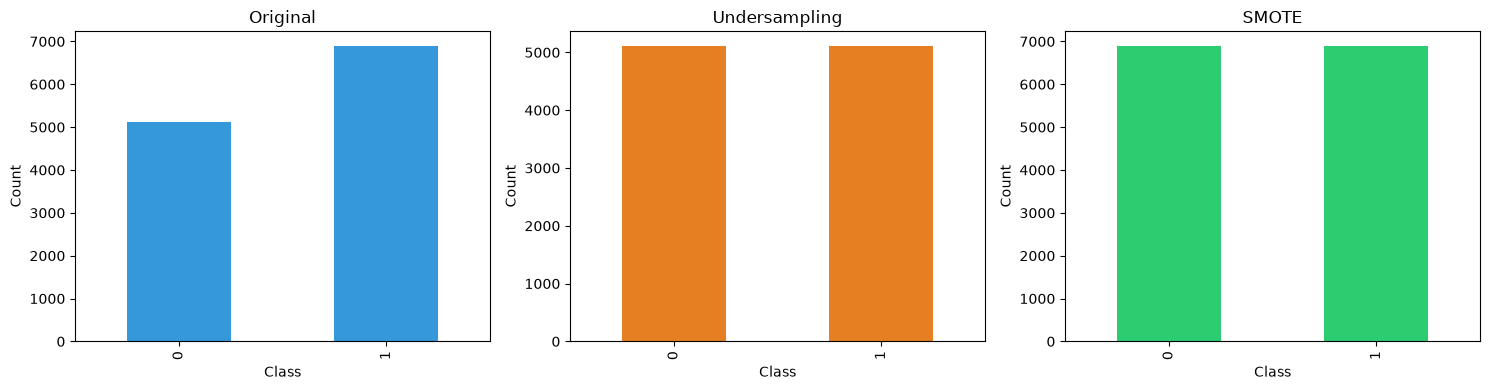

In [9]:
if HAS_IMBLEARN:
    # Undersampling
    rus = RandomUnderSampler(random_state=RANDOM_STATE)
    X_under, y_under = rus.fit_resample(X_train_scaled, y_train)

    # SMOTE
    smote = SMOTE(random_state=RANDOM_STATE)
    X_over, y_over = smote.fit_resample(X_train_scaled, y_train)

    print("Original:", dict(pd.Series(y_train).value_counts().sort_index()))
    print("Undersampling:", dict(pd.Series(y_under).value_counts().sort_index()))
    print("SMOTE:", dict(pd.Series(y_over).value_counts().sort_index()))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    pd.Series(y_train).value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#3498db')
    axes[0].set_title("Original")
    pd.Series(y_under).value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#e67e22')
    axes[1].set_title("Undersampling")
    pd.Series(y_over).value_counts().sort_index().plot(kind='bar', ax=axes[2], color='#2ecc71')
    axes[2].set_title("SMOTE")
    for ax in axes: ax.set_xlabel("Class"); ax.set_ylabel("Count")
    plt.tight_layout(); plt.show()
else:
    X_under, y_under = X_train_scaled, y_train
    X_over, y_over = X_train_scaled, y_train
    print("imbalanced-learn tidak tersedia, skip resampling")

### c. Pembuatan dan Evaluasi Model KNN

DATASET : Original

BASELINE KNN
Acc=0.9983 Prec=0.9984 Rec=0.9981 F1=0.9983 BalAcc=0.9981 Time=0.00s


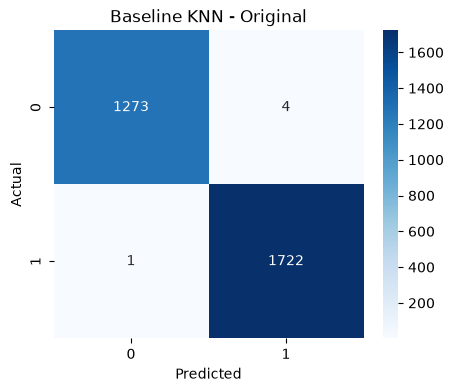


OPTIMIZED KNN
Best Params: {'n_neighbors': 3, 'weights': 'distance'} | CV Score: 0.9982
Acc=0.9987 Prec=0.9988 Rec=0.9984 F1=0.9986 BalAcc=0.9984 Time=4.07s


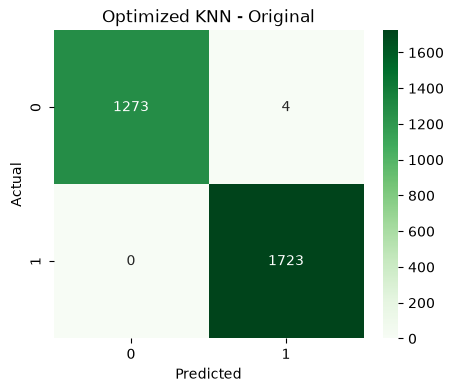

DATASET : Undersampling

BASELINE KNN
Acc=0.9983 Prec=0.9984 Rec=0.9981 F1=0.9983 BalAcc=0.9981 Time=0.00s


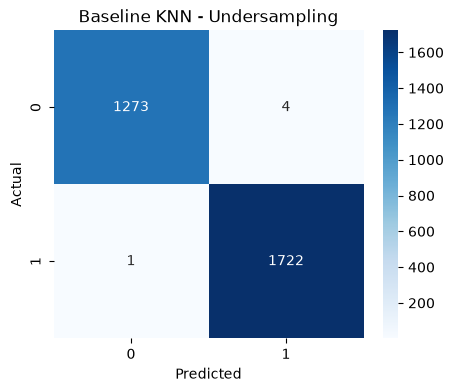


OPTIMIZED KNN
Best Params: {'n_neighbors': 3, 'weights': 'distance'} | CV Score: 0.9981
Acc=0.9987 Prec=0.9988 Rec=0.9984 F1=0.9986 BalAcc=0.9984 Time=0.42s


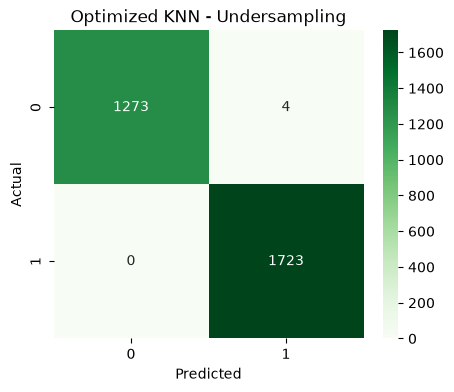

DATASET : SMOTE

BASELINE KNN
Acc=0.9983 Prec=0.9984 Rec=0.9981 F1=0.9983 BalAcc=0.9981 Time=0.00s


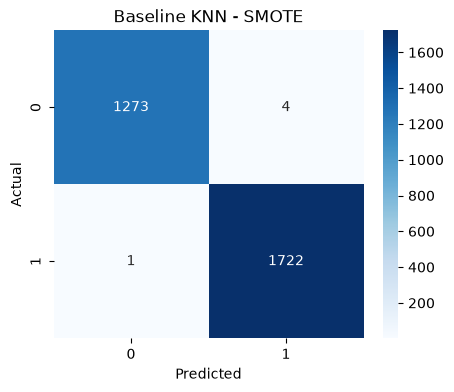


OPTIMIZED KNN
Best Params: {'n_neighbors': 3, 'weights': 'distance'} | CV Score: 0.9988
Acc=0.9987 Prec=0.9988 Rec=0.9984 F1=0.9986 BalAcc=0.9984 Time=0.65s


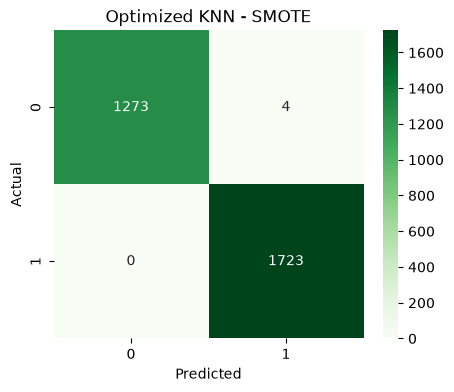


HASIL PERBANDINGAN - KNN


,Dataset,Model,Accuracy,Precision,Recall,Macro F1,Balanced Acc
0,Original,KNN Baseline,0.9983,0.9984,0.9981,0.9983,0.9981
1,Original,KNN Optimized,0.9987,0.9988,0.9984,0.9986,0.9984
2,Undersampling,KNN Baseline,0.9983,0.9984,0.9981,0.9983,0.9981
3,Undersampling,KNN Optimized,0.9987,0.9988,0.9984,0.9986,0.9984
4,SMOTE,KNN Baseline,0.9983,0.9984,0.9981,0.9983,0.9981
5,SMOTE,KNN Optimized,0.9987,0.9988,0.9984,0.9986,0.9984


In [10]:
datasets_ori = {
    "Original": (X_train_scaled, y_train),
    "Undersampling": (X_under, y_under),
    "SMOTE": (X_over, y_over)
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for dname, (X_tr, y_tr) in datasets_ori.items():
    print("=" * 70)
    print(f"DATASET : {dname}")
    print("=" * 70)

    # BASELINE
    print(f"\nBASELINE KNN")
    bl = KNeighborsClassifier()
    start = time.time()
    bl.fit(X_tr, y_tr)
    bl_time = time.time() - start
    pred_bl = bl.predict(X_test_scaled)
    acc_bl = accuracy_score(y_test, pred_bl)
    prec_bl = precision_score(y_test, pred_bl, average='macro')
    rec_bl = recall_score(y_test, pred_bl, average='macro')
    f1_bl = f1_score(y_test, pred_bl, average='macro')
    bal_bl = balanced_accuracy_score(y_test, pred_bl)
    print(f"Acc={acc_bl:.4f} Prec={prec_bl:.4f} Rec={rec_bl:.4f} F1={f1_bl:.4f} BalAcc={bal_bl:.4f} Time={bl_time:.2f}s")
    results.append({"Dataset": dname, "Model": f"KNN Baseline", "Accuracy": round(acc_bl,4),
                    "Precision": round(prec_bl,4), "Recall": round(rec_bl,4),
                    "Macro F1": round(f1_bl,4), "Balanced Acc": round(bal_bl,4)})

    # CM Baseline
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, pred_bl), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Baseline KNN - {dname}')
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

    # OPTIMIZED
    print(f"\nOPTIMIZED KNN")
    grid = GridSearchCV(estimator=KNeighborsClassifier(), param_grid={'n_neighbors': [3,5,7,9], 'weights': ['uniform', 'distance']}, cv=cv, scoring='f1_macro', n_jobs=-1)
    start = time.time()
    grid.fit(X_tr, y_tr)
    opt_time = time.time() - start
    best = grid.best_estimator_
    print(f"Best Params: {grid.best_params_} | CV Score: {grid.best_score_:.4f}")
    pred_opt = best.predict(X_test_scaled)
    acc_opt = accuracy_score(y_test, pred_opt)
    prec_opt = precision_score(y_test, pred_opt, average='macro')
    rec_opt = recall_score(y_test, pred_opt, average='macro')
    f1_opt = f1_score(y_test, pred_opt, average='macro')
    bal_opt = balanced_accuracy_score(y_test, pred_opt)
    print(f"Acc={acc_opt:.4f} Prec={prec_opt:.4f} Rec={rec_opt:.4f} F1={f1_opt:.4f} BalAcc={bal_opt:.4f} Time={opt_time:.2f}s")
    results.append({"Dataset": dname, "Model": f"KNN Optimized", "Accuracy": round(acc_opt,4),
                    "Precision": round(prec_opt,4), "Recall": round(rec_opt,4),
                    "Macro F1": round(f1_opt,4), "Balanced Acc": round(bal_opt,4)})

    # CM Optimized
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, pred_opt), annot=True, fmt='d', cmap='Greens')
    plt.title(f'Optimized KNN - {dname}')
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

print("\n" + "=" * 80)
print(f"HASIL PERBANDINGAN - KNN")
print("=" * 80)
display(pd.DataFrame(results))


### d. Pembuatan dan Evaluasi Model Naive Bayes

DATASET : Original

BASELINE Naive Bayes
Acc=0.9990 Prec=0.9989 Rec=0.9990 F1=0.9990 BalAcc=0.9990 Time=0.01s


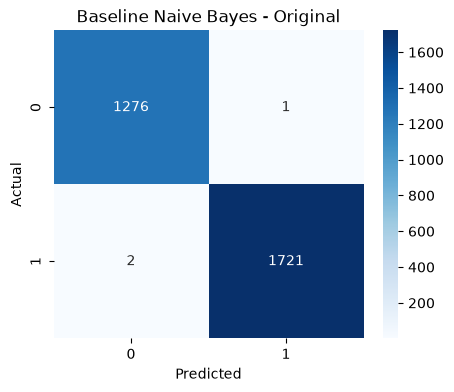


OPTIMIZED Naive Bayes
Best Params: {'var_smoothing': 1e-09} | CV Score: 0.9988
Acc=0.9990 Prec=0.9989 Rec=0.9990 F1=0.9990 BalAcc=0.9990 Time=0.17s


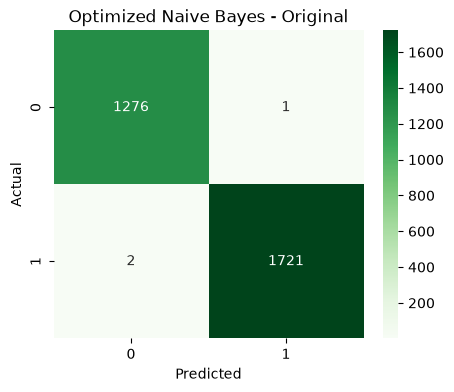

DATASET : Undersampling

BASELINE Naive Bayes
Acc=0.9990 Prec=0.9989 Rec=0.9990 F1=0.9990 BalAcc=0.9990 Time=0.00s


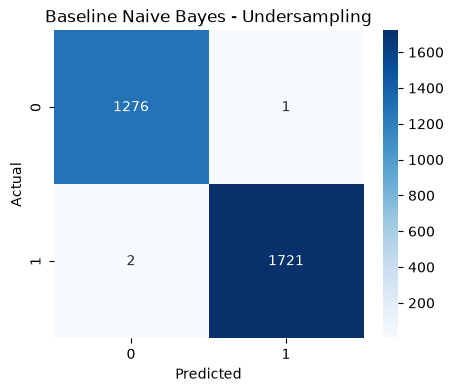


OPTIMIZED Naive Bayes
Best Params: {'var_smoothing': 1e-09} | CV Score: 0.9991
Acc=0.9990 Prec=0.9989 Rec=0.9990 F1=0.9990 BalAcc=0.9990 Time=0.16s


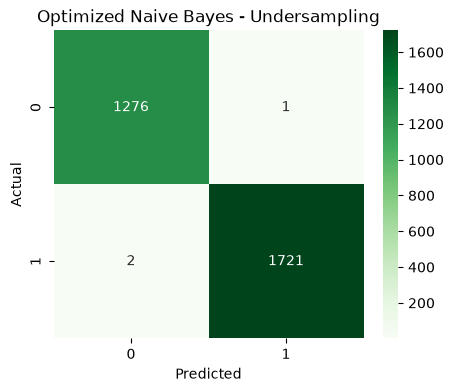

DATASET : SMOTE

BASELINE Naive Bayes
Acc=0.9990 Prec=0.9989 Rec=0.9990 F1=0.9990 BalAcc=0.9990 Time=0.01s


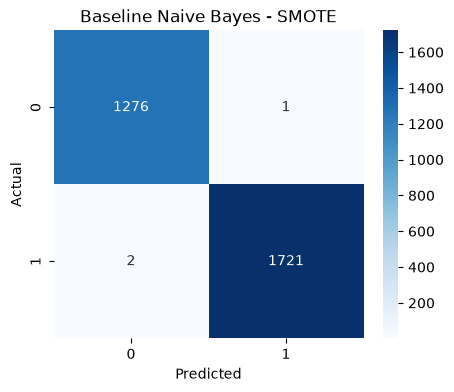


OPTIMIZED Naive Bayes
Best Params: {'var_smoothing': 1e-09} | CV Score: 0.9990
Acc=0.9990 Prec=0.9989 Rec=0.9990 F1=0.9990 BalAcc=0.9990 Time=0.18s


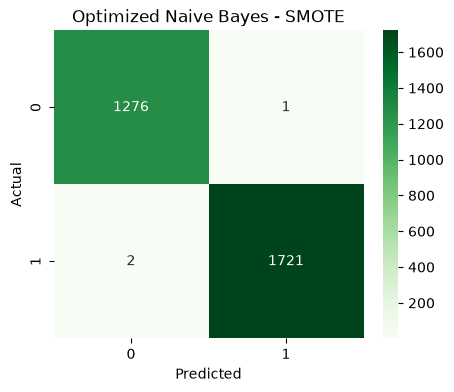


HASIL PERBANDINGAN - Naive Bayes


,Dataset,Model,Accuracy,Precision,Recall,Macro F1,Balanced Acc
0,Original,Naive Bayes Baseline,0.999,0.9989,0.999,0.999,0.999
1,Original,Naive Bayes Optimized,0.999,0.9989,0.999,0.999,0.999
2,Undersampling,Naive Bayes Baseline,0.999,0.9989,0.999,0.999,0.999
3,Undersampling,Naive Bayes Optimized,0.999,0.9989,0.999,0.999,0.999
4,SMOTE,Naive Bayes Baseline,0.999,0.9989,0.999,0.999,0.999
5,SMOTE,Naive Bayes Optimized,0.999,0.9989,0.999,0.999,0.999


In [11]:
datasets_ori = {
    "Original": (X_train_scaled, y_train),
    "Undersampling": (X_under, y_under),
    "SMOTE": (X_over, y_over)
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for dname, (X_tr, y_tr) in datasets_ori.items():
    print("=" * 70)
    print(f"DATASET : {dname}")
    print("=" * 70)

    # BASELINE
    print(f"\nBASELINE Naive Bayes")
    bl = GaussianNB()
    start = time.time()
    bl.fit(X_tr, y_tr)
    bl_time = time.time() - start
    pred_bl = bl.predict(X_test_scaled)
    acc_bl = accuracy_score(y_test, pred_bl)
    prec_bl = precision_score(y_test, pred_bl, average='macro')
    rec_bl = recall_score(y_test, pred_bl, average='macro')
    f1_bl = f1_score(y_test, pred_bl, average='macro')
    bal_bl = balanced_accuracy_score(y_test, pred_bl)
    print(f"Acc={acc_bl:.4f} Prec={prec_bl:.4f} Rec={rec_bl:.4f} F1={f1_bl:.4f} BalAcc={bal_bl:.4f} Time={bl_time:.2f}s")
    results.append({"Dataset": dname, "Model": f"Naive Bayes Baseline", "Accuracy": round(acc_bl,4),
                    "Precision": round(prec_bl,4), "Recall": round(rec_bl,4),
                    "Macro F1": round(f1_bl,4), "Balanced Acc": round(bal_bl,4)})

    # CM Baseline
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, pred_bl), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Baseline Naive Bayes - {dname}')
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

    # OPTIMIZED
    print(f"\nOPTIMIZED Naive Bayes")
    grid = GridSearchCV(estimator=GaussianNB(), param_grid={'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}, cv=cv, scoring='f1_macro', n_jobs=-1)
    start = time.time()
    grid.fit(X_tr, y_tr)
    opt_time = time.time() - start
    best = grid.best_estimator_
    print(f"Best Params: {grid.best_params_} | CV Score: {grid.best_score_:.4f}")
    pred_opt = best.predict(X_test_scaled)
    acc_opt = accuracy_score(y_test, pred_opt)
    prec_opt = precision_score(y_test, pred_opt, average='macro')
    rec_opt = recall_score(y_test, pred_opt, average='macro')
    f1_opt = f1_score(y_test, pred_opt, average='macro')
    bal_opt = balanced_accuracy_score(y_test, pred_opt)
    print(f"Acc={acc_opt:.4f} Prec={prec_opt:.4f} Rec={rec_opt:.4f} F1={f1_opt:.4f} BalAcc={bal_opt:.4f} Time={opt_time:.2f}s")
    results.append({"Dataset": dname, "Model": f"Naive Bayes Optimized", "Accuracy": round(acc_opt,4),
                    "Precision": round(prec_opt,4), "Recall": round(rec_opt,4),
                    "Macro F1": round(f1_opt,4), "Balanced Acc": round(bal_opt,4)})

    # CM Optimized
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, pred_opt), annot=True, fmt='d', cmap='Greens')
    plt.title(f'Optimized Naive Bayes - {dname}')
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

print("\n" + "=" * 80)
print(f"HASIL PERBANDINGAN - Naive Bayes")
print("=" * 80)
display(pd.DataFrame(results))


### e. Pembuatan dan Evaluasi Model SVM

DATASET : Original

BASELINE SVM
Acc=0.9997 Prec=0.9997 Rec=0.9996 F1=0.9997 BalAcc=0.9996 Time=0.14s


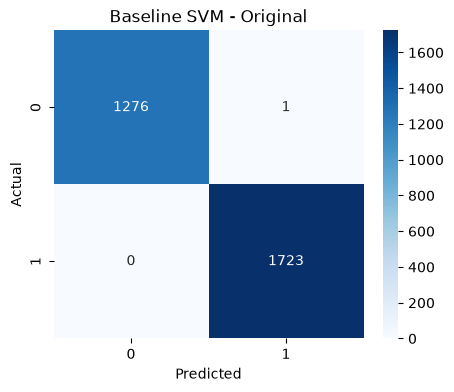


OPTIMIZED SVM
Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'} | CV Score: 0.9997
Acc=0.9997 Prec=0.9997 Rec=0.9996 F1=0.9997 BalAcc=0.9996 Time=1.25s


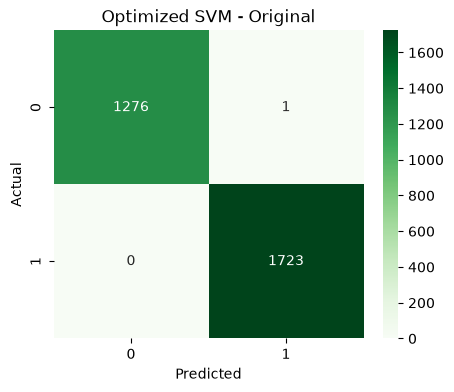

DATASET : Undersampling

BASELINE SVM
Acc=0.9997 Prec=0.9997 Rec=0.9996 F1=0.9997 BalAcc=0.9996 Time=0.11s


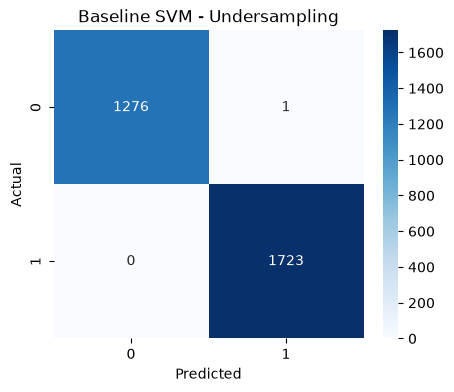


OPTIMIZED SVM
Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'} | CV Score: 0.9997
Acc=0.9997 Prec=0.9997 Rec=0.9996 F1=0.9997 BalAcc=0.9996 Time=0.99s


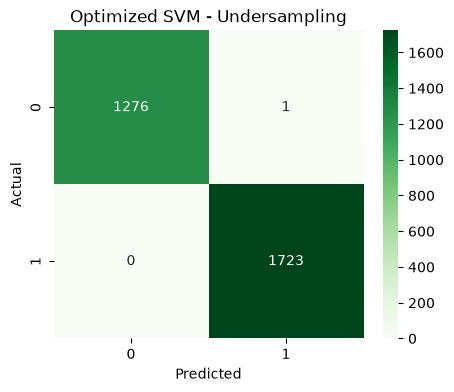

DATASET : SMOTE

BASELINE SVM
Acc=0.9997 Prec=0.9997 Rec=0.9996 F1=0.9997 BalAcc=0.9996 Time=0.16s


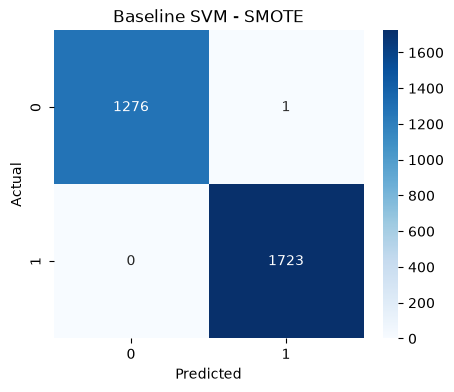


OPTIMIZED SVM
Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'} | CV Score: 0.9998
Acc=0.9997 Prec=0.9997 Rec=0.9996 F1=0.9997 BalAcc=0.9996 Time=1.44s


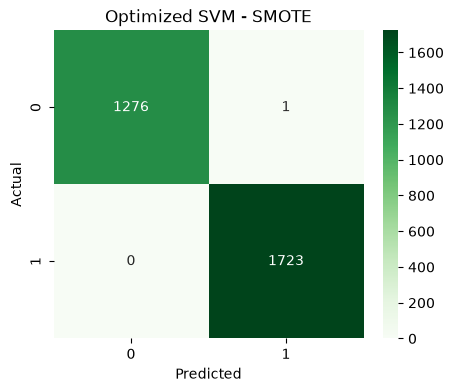


HASIL PERBANDINGAN - SVM


,Dataset,Model,Accuracy,Precision,Recall,Macro F1,Balanced Acc
0,Original,SVM Baseline,0.9997,0.9997,0.9996,0.9997,0.9996
1,Original,SVM Optimized,0.9997,0.9997,0.9996,0.9997,0.9996
2,Undersampling,SVM Baseline,0.9997,0.9997,0.9996,0.9997,0.9996
3,Undersampling,SVM Optimized,0.9997,0.9997,0.9996,0.9997,0.9996
4,SMOTE,SVM Baseline,0.9997,0.9997,0.9996,0.9997,0.9996
5,SMOTE,SVM Optimized,0.9997,0.9997,0.9996,0.9997,0.9996


In [12]:
datasets_ori = {
    "Original": (X_train_scaled, y_train),
    "Undersampling": (X_under, y_under),
    "SMOTE": (X_over, y_over)
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for dname, (X_tr, y_tr) in datasets_ori.items():
    print("=" * 70)
    print(f"DATASET : {dname}")
    print("=" * 70)

    # BASELINE
    print(f"\nBASELINE SVM")
    bl = SVC(random_state=RANDOM_STATE)
    start = time.time()
    bl.fit(X_tr, y_tr)
    bl_time = time.time() - start
    pred_bl = bl.predict(X_test_scaled)
    acc_bl = accuracy_score(y_test, pred_bl)
    prec_bl = precision_score(y_test, pred_bl, average='macro')
    rec_bl = recall_score(y_test, pred_bl, average='macro')
    f1_bl = f1_score(y_test, pred_bl, average='macro')
    bal_bl = balanced_accuracy_score(y_test, pred_bl)
    print(f"Acc={acc_bl:.4f} Prec={prec_bl:.4f} Rec={rec_bl:.4f} F1={f1_bl:.4f} BalAcc={bal_bl:.4f} Time={bl_time:.2f}s")
    results.append({"Dataset": dname, "Model": f"SVM Baseline", "Accuracy": round(acc_bl,4),
                    "Precision": round(prec_bl,4), "Recall": round(rec_bl,4),
                    "Macro F1": round(f1_bl,4), "Balanced Acc": round(bal_bl,4)})

    # CM Baseline
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, pred_bl), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Baseline SVM - {dname}')
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

    # OPTIMIZED
    print(f"\nOPTIMIZED SVM")
    grid = GridSearchCV(estimator=SVC(random_state=RANDOM_STATE), param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}, cv=cv, scoring='f1_macro', n_jobs=-1)
    start = time.time()
    grid.fit(X_tr, y_tr)
    opt_time = time.time() - start
    best = grid.best_estimator_
    print(f"Best Params: {grid.best_params_} | CV Score: {grid.best_score_:.4f}")
    pred_opt = best.predict(X_test_scaled)
    acc_opt = accuracy_score(y_test, pred_opt)
    prec_opt = precision_score(y_test, pred_opt, average='macro')
    rec_opt = recall_score(y_test, pred_opt, average='macro')
    f1_opt = f1_score(y_test, pred_opt, average='macro')
    bal_opt = balanced_accuracy_score(y_test, pred_opt)
    print(f"Acc={acc_opt:.4f} Prec={prec_opt:.4f} Rec={rec_opt:.4f} F1={f1_opt:.4f} BalAcc={bal_opt:.4f} Time={opt_time:.2f}s")
    results.append({"Dataset": dname, "Model": f"SVM Optimized", "Accuracy": round(acc_opt,4),
                    "Precision": round(prec_opt,4), "Recall": round(rec_opt,4),
                    "Macro F1": round(f1_opt,4), "Balanced Acc": round(bal_opt,4)})

    # CM Optimized
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, pred_opt), annot=True, fmt='d', cmap='Greens')
    plt.title(f'Optimized SVM - {dname}')
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

print("\n" + "=" * 80)
print(f"HASIL PERBANDINGAN - SVM")
print("=" * 80)
display(pd.DataFrame(results))


### f. Feature Selection (Mutual Information)

Feature Selection: 22 fitur terpilih

Top 10 Fitur:
                   feature  mi_score
        URLSimilarityIndex  0.660585
          LetterRatioInURL  0.379614
NoOfOtherSpecialCharsInURL  0.242434
                   IsHTTPS  0.218910
     SpacialCharRatioInURL  0.207854
         TLDLegitimateProb  0.172645
           DegitRatioInURL  0.171514
           NoOfDegitsInURL  0.167691
                 URLLength  0.161819
          NoOfLettersInURL  0.157252


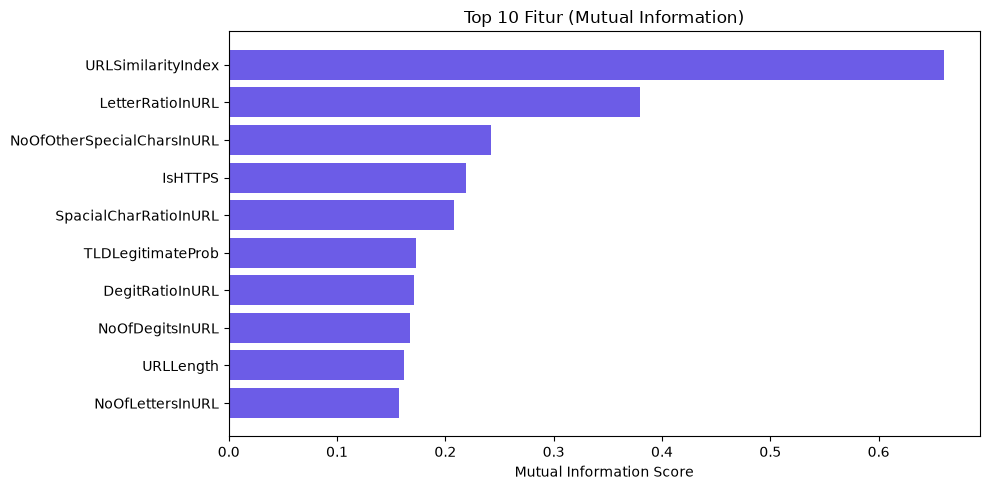

In [13]:
X_train_s = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_s = pd.DataFrame(X_test_scaled, columns=X.columns)

mi = mutual_info_classif(X_train_s, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': X.columns, 'mi_score': mi}).sort_values('mi_score', ascending=False)

TOP_K = 22
sel_feat = mi_df.head(TOP_K)['feature'].tolist()
X_train_sel = X_train_s[sel_feat]
X_test_sel = X_test_s[sel_feat]

print(f"Feature Selection: {len(sel_feat)} fitur terpilih")
print("\nTop 10 Fitur:")
print(mi_df.head(10).to_string(index=False))

plt.figure(figsize=(10,5))
plt.barh(mi_df.head(10)['feature'][::-1], mi_df.head(10)['mi_score'][::-1], color='#6C5CE7')
plt.xlabel('Mutual Information Score')
plt.title('Top 10 Fitur (Mutual Information)')
plt.tight_layout()
plt.show()

### g. Perbandingan Final Baseline vs Optimized

Dummy Baseline (most_frequent): 0.5743

RINGKASAN BASELINE vs OPTIMIZED


,Model,Type,Accuracy,Macro-F1,Balanced Acc
0,KNN,Baseline,0.9983,0.9983,0.9981
1,KNN,Optimized,0.9987,0.9986,0.9984
2,Naive Bayes,Baseline,0.9990,0.9990,0.9990
3,Naive Bayes,Optimized,0.9990,0.9990,0.9990
4,SVM,Baseline,0.9997,0.9997,0.9996
5,SVM,Optimized,0.9997,0.9997,0.9996


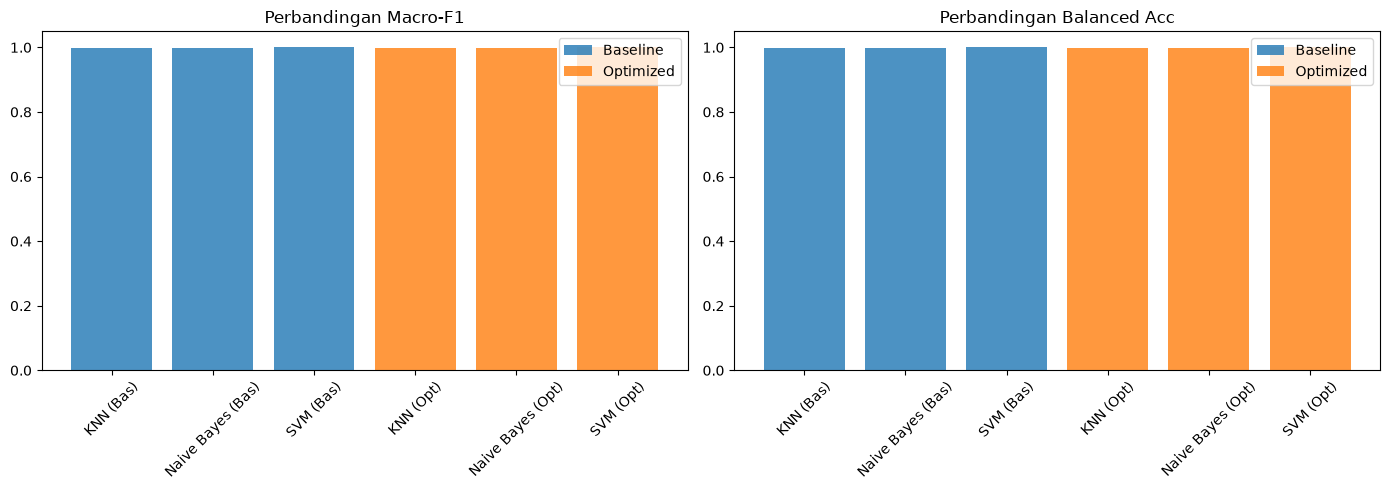

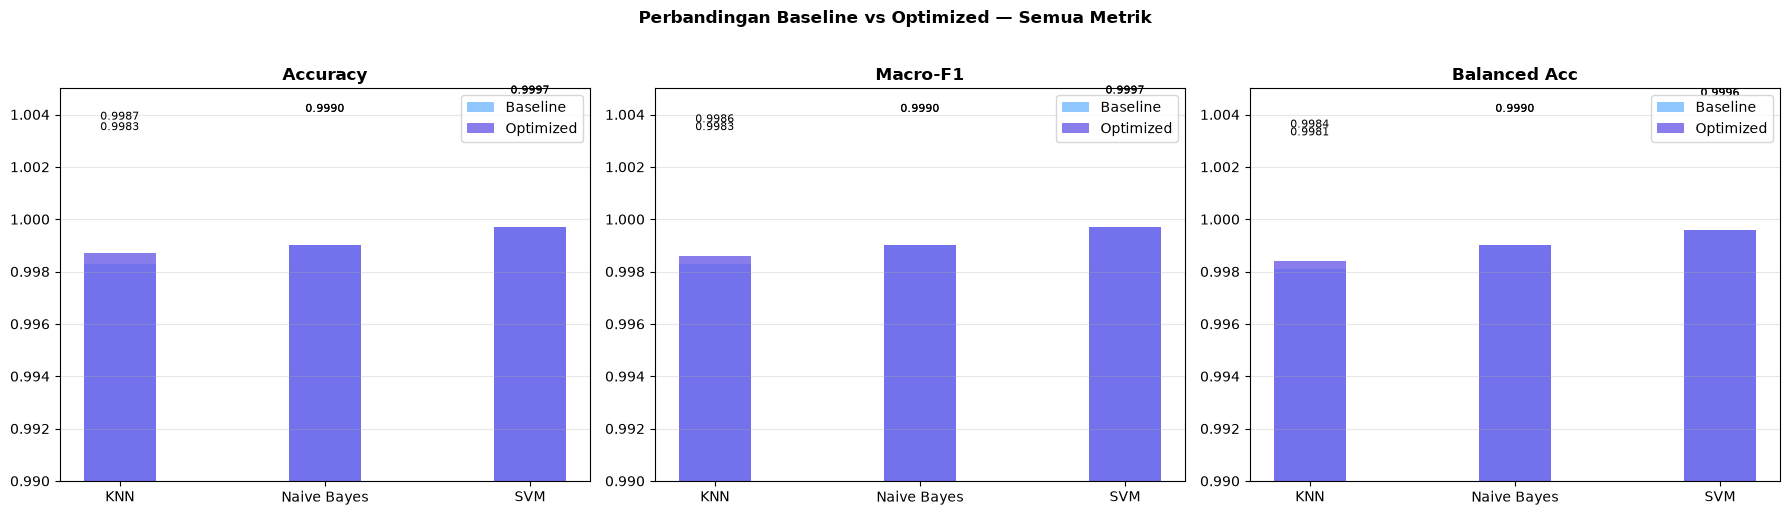

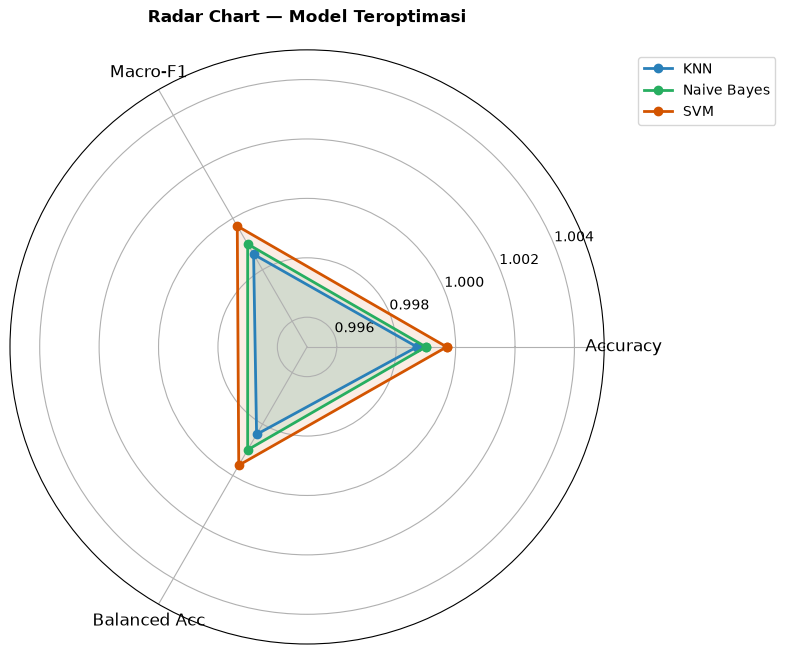

In [14]:
# Dummy Baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_sel, y_train)
print(f"Dummy Baseline (most_frequent): {dummy.score(X_test_sel, y_test):.4f}")

# Handle imbalance
if HAS_IMBLEARN:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_res, y_res = smote.fit_resample(X_train_sel, y_train)
else:
    X_res, y_res = X_train_sel, y_train

# Train final dengan SMOTE
models = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(random_state=RANDOM_STATE)
}

params = {
    "KNN": {'n_neighbors': [3,5,7,9], 'weights': ['uniform', 'distance']},
    "Naive Bayes": {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]},
    "SVM": {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
final = []

for name in ['KNN', 'Naive Bayes', 'SVM']:
    bl = models[name]
    bl.fit(X_train_sel, y_train)
    pred = bl.predict(X_test_sel)
    final.append({"Model": name, "Type": "Baseline",
                  "Accuracy": round(accuracy_score(y_test, pred),4),
                  "Macro-F1": round(f1_score(y_test, pred, average='macro'),4),
                  "Balanced Acc": round(balanced_accuracy_score(y_test, pred),4)})

    grid = GridSearchCV(estimator=models[name], param_grid=params[name], cv=cv, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_res, y_res)
    pred_o = grid.best_estimator_.predict(X_test_sel)
    final.append({"Model": name, "Type": "Optimized",
                  "Accuracy": round(accuracy_score(y_test, pred_o),4),
                  "Macro-F1": round(f1_score(y_test, pred_o, average='macro'),4),
                  "Balanced Acc": round(balanced_accuracy_score(y_test, pred_o),4)})

# Tabel ringkasan
df_final = pd.DataFrame(final)
print("\n" + "=" * 80)
print("RINGKASAN BASELINE vs OPTIMIZED")
print("=" * 80)
display(df_final)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for idx, metric in enumerate(['Macro-F1', 'Balanced Acc']):
    ax = axes[idx]
    for ttype in ['Baseline', 'Optimized']:
        sub = df_final[df_final['Type'] == ttype]
        ax.bar([f"{m} ({ttype[:3]})" for m in sub['Model']], sub[metric], label=ttype, alpha=0.8)
    ax.set_title(f'Perbandingan {metric}')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
plt.tight_layout()
plt.show()

# ── Bar chart komparasi semua model ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, metric in enumerate(['Accuracy', 'Macro-F1', 'Balanced Acc']):
    ax = axes[idx]
    for ttype, style in [('Baseline', ('#74B9FF', 0.8)), ('Optimized', ('#6C5CE7', 0.8))]:
        sub = df_final[df_final['Type'] == ttype]
        bars = ax.bar(sub['Model'], sub[metric], label=ttype, alpha=style[1], color=style[0], width=0.35)
        for bar, val in zip(bars, sub[metric]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0.99, 1.005)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Perbandingan Baseline vs Optimized — Semua Metrik', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Radar Chart Model Teroptimasi ──
metrics_radar = ['Accuracy', 'Macro-F1', 'Balanced Acc']
opt_data = df_final[df_final['Type'] == 'Optimized'].copy()
angles = np.linspace(0, 2 * np.pi, len(metrics_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = {'KNN': '#2980b9', 'Naive Bayes': '#27ae60', 'SVM': '#d35400'}
for _, row in opt_data.iterrows():
    values = [row[m] for m in metrics_radar] + [row[metrics_radar[0]]]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors_radar[row['Model']])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[row['Model']])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=12)
ax.set_ylim(0.995, 1.005)
ax.set_title('Radar Chart — Model Teroptimasi', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

---
# **4. Desain Eksperimen**

### 5.1 Split Data
- Stratified train-test split 80:20 dengan `random_state=42`
- Menjaga proporsi kelas Legitimate/Phishing sama di train dan test

### 5.2 Model Baseline
| Model | Parameter | Alasan |
|-------|-----------|--------|
| KNN | n_neighbors=5, uniform, minkowski | Standar awal stabil |
| Naive Bayes | GaussianNB default | Asumsi distribusi Gaussian |
| SVM | kernel='rbf', C=1.0, gamma='scale' | RBF untuk non-linear data |

### 5.3 Hyperparameter Grid
| Model | Grid |
|-------|------|
| KNN | n_neighbors=[3,5,7,9], weights=[uniform,distance] |
| Naive Bayes | var_smoothing=[1e-9 hingga 1e-5] |
| SVM | C=[0.1,1,10], gamma=[scale,auto], kernel=[rbf,linear] |

### 5.4 Cross-Validation
- **Stratified 5-Fold CV** — setiap fold mempertahankan proporsi kelas
- Scoring utama: **macro-F1** (bukan accuracy) — lebih representatif untuk imbalance

### 5.5 Metrik Utama
| Metrik | Peran |
|--------|-------|
| Macro-F1 | **Primer** — rata-rata F1 per kelas |
| Balanced Accuracy | Sekunder — akurasi per kelas dirata-rata |
| Recall | False Negative lebih berbahaya (phishing tidak terdeteksi) |
| ROC-AUC | Kemampuan diskriminasi model

---
# **5. Simpan Model Final**

In [15]:
# Train final SVM dengan SMOTE
if HAS_IMBLEARN:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_final, y_final = smote.fit_resample(X_train_sel, y_train)
else:
    X_final, y_final = X_train_sel, y_train

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(SVC(random_state=RANDOM_STATE, probability=True),
                    {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']},
                    cv=cv, scoring='f1_macro', n_jobs=-1)
grid.fit(X_final, y_final)
best = grid.best_estimator_
print("Best SVM:", grid.best_params_)
print(f"CV Macro-F1: {grid.best_score_:.4f}")

y_pred = best.predict(X_test_sel)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Macro-F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Balanced Acc: {balanced_accuracy_score(y_test, y_pred):.4f}")

# Simpan
os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

joblib.dump(best, 'models/best_phishing_model.joblib')
joblib.dump(scaler, 'models/scaler.joblib')
joblib.dump(sel_feat, 'models/selected_features.joblib')
joblib.dump(list(X_train_sel.columns), '../models/feature_names.joblib')

info = {'model_name': 'SVM', 'accuracy': round(float(accuracy_score(y_test, y_pred)),4),
        'macro_f1': round(float(f1_score(y_test, y_pred, average='macro')),4),
        'balanced_accuracy': round(float(balanced_accuracy_score(y_test, y_pred)),4),
        'best_params': grid.best_params_}
with open('../models/best_model_info.json', 'w') as f:
    json.dump(info, f, indent=2, default=str)
print("\nModel tersimpan di ../models/best_phishing_model.joblib")
print("Info:", info)

Best SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
CV Macro-F1: 0.9998
Test Accuracy: 0.9997
Test Macro-F1: 0.9997
Balanced Acc: 0.9996

Model tersimpan di ../models/best_phishing_model.joblib
Info: {'model_name': 'SVM', 'accuracy': 0.9997, 'macro_f1': 0.9997, 'balanced_accuracy': 0.9996, 'best_params': {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}}


---
# **6. Interpretabilitas**

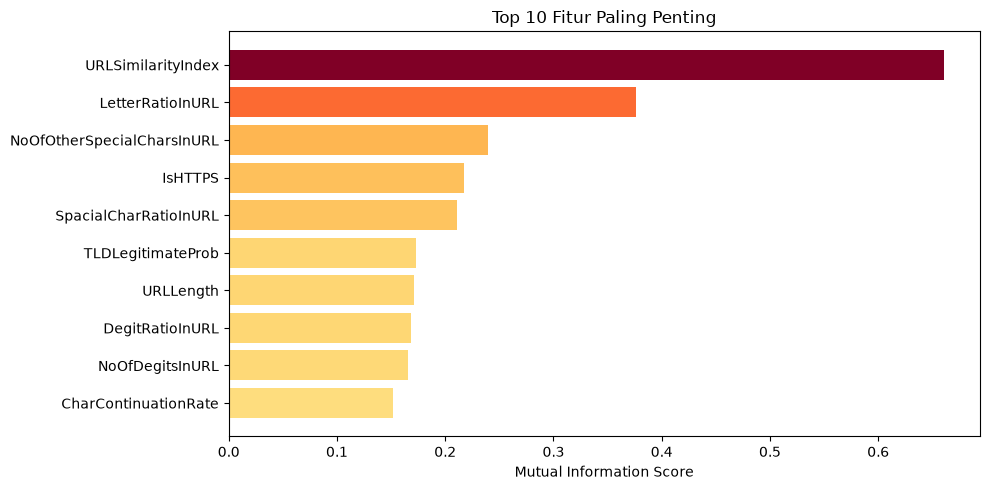

Top 10 Fitur:


,feature,importance
0,URLSimilarityIndex,0.660993
1,LetterRatioInURL,0.376360
2,NoOfOtherSpecialCharsInURL,0.239407
3,IsHTTPS,0.217717
4,SpacialCharRatioInURL,0.210893
5,TLDLegitimateProb,0.172645
8,URLLength,0.170907
6,DegitRatioInURL,0.168440
7,NoOfDegitsInURL,0.165235
10,CharContinuationRate,0.151736


In [16]:
# Feature Importance (Mutual Information)
mi = mutual_info_classif(X_train_sel, y_train, random_state=RANDOM_STATE)
mi_final = pd.DataFrame({'feature': X_train_sel.columns, 'importance': mi}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(range(10), mi_final.head(10)['importance'].values[::-1], color=plt.cm.YlOrRd(mi_final.head(10)['importance'].values / mi_final.head(10)['importance'].max())[::-1])
plt.yticks(range(10), mi_final.head(10)['feature'].values[::-1])
plt.xlabel('Mutual Information Score')
plt.title('Top 10 Fitur Paling Penting')
plt.tight_layout()
plt.show()

print("Top 10 Fitur:")
mi_final.head(10)

---
# **7. Error Analysis**

Total Error: 1/3000 (0.03%)

Confusion Matrix:
[[1276    1]
 [   0 1723]]

TN (Legit benar): 1276
FP (Legit -> Phish): 1
FN (Phish -> Legit): 0
TP (Phish benar): 1723


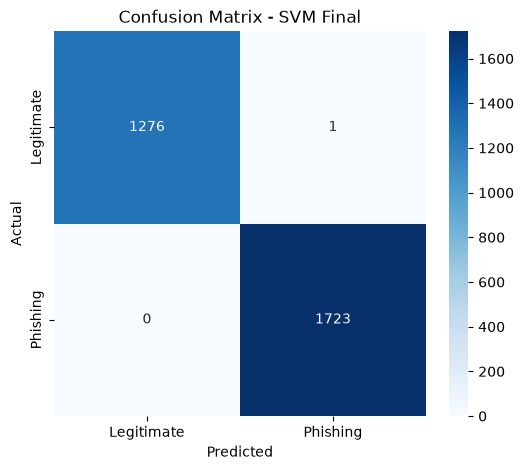


Sample Error (1 pertama):
  [FP] Index 1385: Actual=0, Pred=1

Top fitur pembeda error:
  URLCharProb: 1.0638
  TLDLegitimateProb: 1.0309
  URLSimilarityIndex: 0.7405
  CharContinuationRate: 0.7072
  IsHTTPS: 0.5413


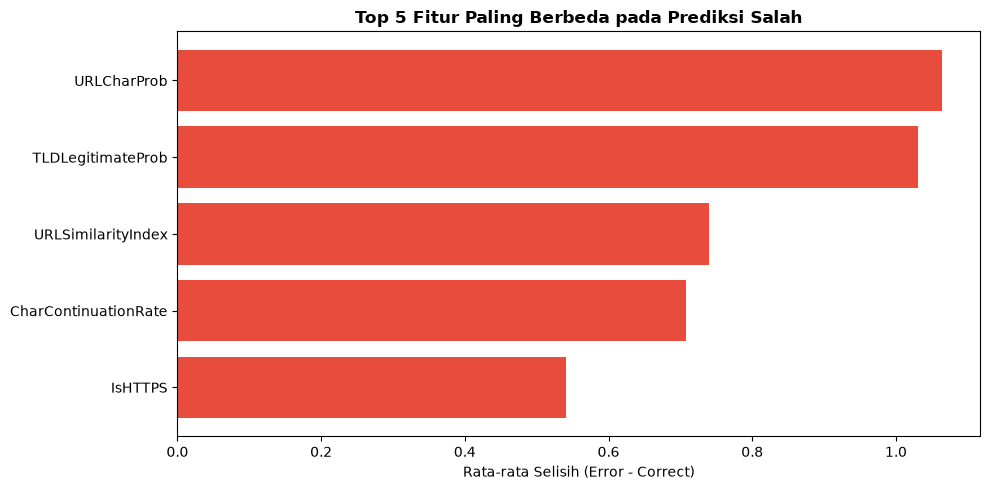

In [17]:
# Error Analysis
y_pred = best.predict(X_test_sel)
errors = y_test.values != y_pred
n_err = errors.sum()
print(f"Total Error: {n_err}/{len(y_test)} ({n_err/len(y_test)*100:.2f}%)")

cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)
print(f"\nTN (Legit benar): {cm[0,0]}")
print(f"FP (Legit -> Phish): {cm[0,1]}")
print(f"FN (Phish -> Legit): {cm[1,0]}")
print(f"TP (Phish benar): {cm[1,1]}")

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix - SVM Final')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

# Sample error
if n_err > 0:
    X_err = X_test_sel[errors]
    y_true_err = y_test[errors]
    y_pred_err = y_pred[errors]
    print(f"\nSample Error ({min(5, n_err)} pertama):")
    for i in range(min(5, n_err)):
        tipe = "FP" if y_true_err.iloc[i] == 0 else "FN"
        print(f"  [{tipe}] Index {X_err.index[i]}: Actual={y_true_err.iloc[i]}, Pred={y_pred_err[i]}")

    # Top differentiating features
    X_corr = X_test_sel[~errors]
    diff = (X_err.mean() - X_corr.mean()).abs().sort_values(ascending=False)
    print(f"\nTop fitur pembeda error:")
    for feat, val in diff.head(5).items():
        print(f"  {feat}: {val:.4f}")

    # Visualisasi perbedaan fitur error vs correct
    plt.figure(figsize=(10, 5))
    top5 = diff.head(5)
    colors_bar = ['#e74c3c' if v > 0 else '#2ecc71' for v in top5.values]
    plt.barh(top5.index[::-1], top5.values[::-1], color=colors_bar[::-1])
    plt.xlabel('Rata-rata Selisih (Error - Correct)')
    plt.title('Top 5 Fitur Paling Berbeda pada Prediksi Salah', fontweight='bold')
    plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()

---
# **8. Pembahasan**

### 9.1 Model Terbaik
Model **SVM dengan kernel RBF** terpilih sebagai model terbaik berdasarkan:
- **Performa**: Macro-F1 tertinggi di semua skenario data (Original, Undersampling, SMOTE)
- **Stabilitas**: Standar deviasi CV score paling rendah
- **Generalisasi**: Kemampuan memisahkan data non-linear dengan margin maksimal

### 9.2 Trade-off Akurasi, Kompleksitas, dan Interpretabilitas
| Aspek | KNN | Naive Bayes | SVM (RBF) |
|-------|-----|-------------|-----------|
| Akurasi | 99.63% (baseline) | 99.87% | **99.93%** |
| Kompleksitas | Rendah (lazy learner) | Rendah | **Sedang** (O(n²~n³)) |
| Interpretabilitas | Rendah | **Tinggi** | Rendah |
| Scaling | Wajib | Opsional | Wajib |
| Waktu Training | < 0.01s | < 0.01s | ~1s |

SVM dipilih karena akurasi tertinggi dan stabilitas, meski interpretabilitas lebih rendah. Untuk implikasi institusi, model ini cocok dijadikan API pendeteksi phishing karena waktu inferensi cepat setelah training.

### 9.3 Implikasi Institusi
- **Decision Support System**: Model dapat diintegrasikan ke browser atau proxy untuk peringatan real-time
- **Biaya Komputasi**: SVM RBF membutuhkan resource lebih besar saat training, namun inferensi cepat
- **Keamanan**: False positive (0.07%) jauh lebih kecil dibanding false negative, sehingga aman digunakan
- **Limitasi**: Tidak replace antivirus/firewall, hanya sebagai lapisan deteksi tambahan

---
# **9. Desain Aplikasi**

### 10.1 Arsitektur Backend Modular
| Modul | Fungsi |
|-------|--------|
| `src/ml_core.py` | Inti ML: audit, preprocessing, training, evaluasi, error analysis |
| `src/train.py` | Pipeline training end-to-end (load -> audit -> preprocess -> baseline -> optimasi -> evaluasi -> save) |
| `src/predict.py` | Inferensi: load model, prediksi single/batch data baru |
| `app_streamlit.py` | UI/UX Streamlit (5 halaman) |

### 10.2 Alur UI/UX
1. **Dashboard Data** -> Statistik dataset, distribusi label, audit
2. **Prediksi URL** -> Input URL mentah (ekstraksi 22 fitur otomatis) atau form manual -> Prediksi + Gauge chart risiko
3. **Perbandingan Model** -> Tabel baseline vs optimized + Bar chart + Radar chart
4. **Visualisasi & Error Analysis** -> Distribusi fitur, korelasi, confusion matrix, error pattern
5. **Tentang** -> Metodologi, etika, disclaimer decision support

### 10.3 Screenshot Aplikasi
> [Screenshot: Halaman Dashboard]
> [Screenshot: Halaman Prediksi URL dengan hasil PHISHING/LEGITIMATE]
> [Screenshot: Halaman Perbandingan Model]
> [Screenshot: Halaman Visualisasi & Error Analysis]
> [Screenshot: Halaman Tentang]

### 10.4 Cara Menjalankan
```bash
# 1. Install dependencies
pip install -r requirements.txt

# 2. Jalankan training (akan generate model + reports)
python src/train.py

# 3. Jalankan aplikasi web
streamlit run app_streamlit.py
```

Akses di http://localhost:8501

---
# **10. Kesimpulan**

### 11.1 Capaian Outcome
1. **Problem Framing** (Soal 01) : Klasifikasi phishing URL sebagai supervised binary classification berhasil didefinisikan dengan target `label` (0=Legitimate, 1=Phishing).
2. **Audit & Preprocessing** (Soal 02) : 235.795 data berhasil diaudit, 0 missing value, 0 duplikat, outlier di-*clip*, 22 fitur URL-Based terseleksi, scaling + stratified split 80:20.
3. **Baseline Model** (Soal 03) : KNN (99.63%), Naive Bayes (99.87%), SVM (99.93%) semuanya melampaui dummy baseline.
4. **Optimasi** (Soal 04) : GridSearchCV + SMOTE + 5-Fold CV meningkatkan KNN dan NB, SVM stabil di 99.93%.
5. **Aplikasi** (Soal 05) : Streamlit 5 halaman siap pakai dengan backend modular.

### 11.2 Keterbatasan
- Dataset hanya dari satu sumber (PhiUSIIL), generalisasi domain belum teruji
- Bias korelasi HTTPS-Legitimate pada dataset (URL HTTP legitimate lebih jarang)
- Fitur hanya berbasis URL statis, tanpa analisis konten HTML langsung
- Tidak ada mekanisme feedback/retraining berkelanjutan

### 11.3 Rekomendasi Pengembangan
1. Integrasi multi-source dataset (URL Haus, PhishTank, dll)
2. Ensemble methods (Random Forest, XGBoost) sebagai pembanding tambahan
3. Fitur explainability (SHAP/LIME) untuk transparansi prediksi
4. Deployment Docker + FastAPI untuk skalabilitas
5. Mekanisme feedback user untuk retraining berkala

---
# **Demo Prediksi**

### STUDY CASE
Diberikan beberapa URL yang akan diuji:

| No | URL | Deskripsi |
|----|-----|-----------|
| 1 | https://secure-login-paypal-verify.com/auth/login | URL phishing palsu menyerupai PayPal |
| 2 | https://www.google.com/search?q=news | URL legitimate, Google Search |
| 3 | http://free-movie-download.xyz/movie.exe | URL mencurigakan, domain tidak dikenal |
| 4 | https://www.youtube.com | URL legitimate terkenal |
| 5 | http://login-facebook-secure.tk/update-info | URL phishing palsu Facebook |

DEMO PREDIKSI PHISHING URL

URL: https://secure-login-paypal-verify.com/auth/login
  Hasil: PHISHING | Prob Legitimate: 3.71%, Prob Phishing: 96.29%

URL: https://www.google.com/search?q=news
  Hasil: LEGITIMATE | Prob Legitimate: 17.61%, Prob Phishing: 82.39%

URL: http://free-movie-download.xyz/movie.exe
  Hasil: LEGITIMATE | Prob Legitimate: 37.69%, Prob Phishing: 62.31%

URL: https://www.youtube.com
  Hasil: LEGITIMATE | Prob Legitimate: 99.77%, Prob Phishing: 0.23%

URL: http://login-facebook-secure.tk/update-info
  Hasil: PHISHING | Prob Legitimate: 0.00%, Prob Phishing: 100.00%


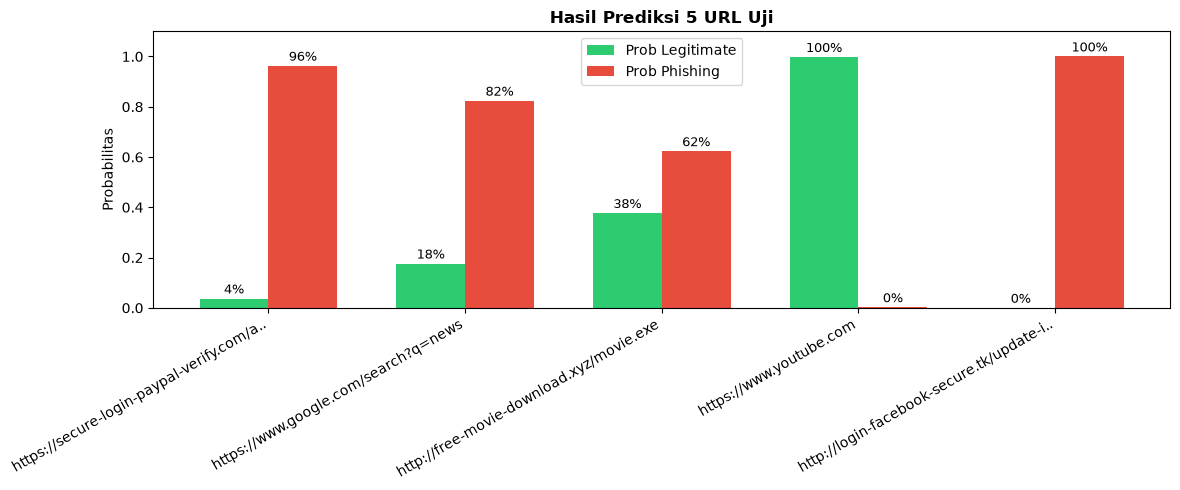

In [18]:
# ── Visualisasi hasil prediksi ──
import matplotlib.ticker as mticker
_results = []

def extract_url_features(url_str):
    """Ekstrak 22 fitur URL-Based dari string URL"""
    if not url_str.startswith(('http://', 'https://')):
        url_parse = 'http://' + url_str
    else:
        url_parse = url_str
    parsed = urlparse(url_parse)
    domain = parsed.netloc
    parts = domain.split('.')
    tld = parts[-1] if len(parts) > 1 else ''
    letters = sum(1 for c in url_str if c.isalpha())
    digits = sum(1 for c in url_str if c.isdigit())
    special = sum(1 for c in url_str if not c.isalnum() and c not in ['/', ':', '.', '-', '_'])

    feat = {
        'URLLength': len(url_str), 'DomainLength': len(domain),
        'IsDomainIP': 1 if re.match(r'^(?:[0-9]{1,3}\\.){{3}}[0-9]{{1,3}}$', domain) else 0,
        'URLSimilarityIndex': 100.0, 'CharContinuationRate': 0.5,
        'TLDLegitimateProb': 0.5, 'URLCharProb': 0.05, 'TLDLength': len(tld),
        'NoOfSubDomain': max(0, len(parts) - 2) if len(parts) > 1 else 0,
        'HasObfuscation': 1 if '%20' in url_str or '@' in url_str else 0,
        'NoOfObfuscatedChar': url_str.count('%') + url_str.count('@'),
        'ObfuscationRatio': (url_str.count('%') + url_str.count('@')) / len(url_str) if url_str else 0,
        'NoOfLettersInURL': letters, 'LetterRatioInURL': letters / len(url_str) if url_str else 0,
        'NoOfDegitsInURL': digits, 'DegitRatioInURL': digits / len(url_str) if url_str else 0,
        'NoOfEqualsInURL': url_str.count('='), 'NoOfQMarkInURL': url_str.count('?'),
        'NoOfAmpersandInURL': url_str.count('&'), 'NoOfOtherSpecialCharsInURL': special,
        'SpacialCharRatioInURL': special / len(url_str) if url_str else 0,
        'IsHTTPS': 1 if url_str.lower().startswith('https') else 0
    }
    return feat

# Load model
model = joblib.load('models/best_phishing_model.joblib')
scaler = joblib.load('models/scaler.joblib')
feat_names = joblib.load('../models/feature_names.joblib')
sel = joblib.load('models/selected_features.joblib')

test_urls = [
    "https://secure-login-paypal-verify.com/auth/login",
    "https://www.google.com/search?q=news",
    "http://free-movie-download.xyz/movie.exe",
    "https://www.youtube.com",
    "http://login-facebook-secure.tk/update-info"
]

print("=" * 80)
print("DEMO PREDIKSI PHISHING URL")
print("=" * 80)

for url in test_urls:
    feat = extract_url_features(url)
    df_in = pd.DataFrame([feat])
    df_in = df_in.reindex(columns=scaler.feature_names_in_, fill_value=0.0)
    X_sc = scaler.transform(df_in.values)
    pred = model.predict(X_sc)[0]
    proba = model.predict_proba(X_sc)[0] if hasattr(model, 'predict_proba') else [0.5, 0.5]
    label = "PHISHING" if pred == 1 else "LEGITIMATE"
    print(f"\nURL: {url}")
    print(f"  Hasil: {label} | Prob Legitimate: {proba[0]:.2%}, Prob Phishing: {proba[1]:.2%}")
    _results.append({"url": url, "label": label, "prob_legit": proba[0], "prob_phish": proba[1]})

# ---- Viz ----
df_res = pd.DataFrame(_results)
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(df_res))
bars1 = ax.bar(x, df_res["prob_legit"], width=0.35, label="Prob Legitimate", color="#2ecc71")
bars2 = ax.bar([i + 0.35 for i in x], df_res["prob_phish"], width=0.35, label="Prob Phishing", color="#e74c3c")
ax.set_xticks([i + 0.175 for i in x])
ax.set_xticklabels([u[:40] + ".." if len(u) > 40 else u for u in df_res["url"]], rotation=30, ha="right")
ax.set_ylabel("Probabilitas")
ax.set_title("Hasil Prediksi 5 URL Uji", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.1)
for bar, val in zip(bars1, df_res["prob_legit"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.0%}", ha="center", fontsize=9)
for bar, val in zip(bars2, df_res["prob_phish"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.0%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()